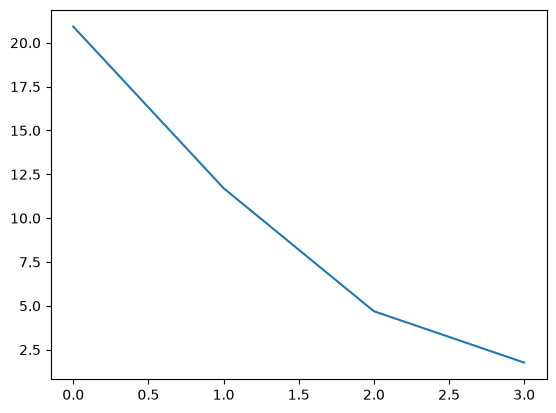

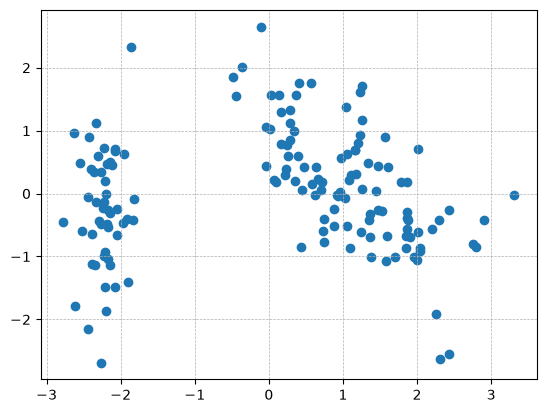

In [17]:
'''
1. 用一个真实的数据集（如鸢尾花、手写数字），做 SVD 分解，分析奇异值的衰减。
2. 用 SVD 做 PCA，可视化降维后的数据。
3. 用 SVD 做图像压缩（用 `plt.imshow` 展示不同 $k$ 值的效果）。
4. 用伪逆 `np.linalg.pinv` 解一个最小二乘问题，与 `np.linalg.lstsq` 对比。
'''

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from PIL import Image
# 1. 用一个真实的数据集（如鸢尾花、手写数字），做 SVD 分解，分析奇异值的衰减。
iris = load_iris()
X = iris.data
X = StandardScaler().fit_transform(X)
U, S, Vt = np.linalg.svd(X)
plt.plot(S)
plt.show()

# 2. 用 SVD 做 PCA，可视化降维后的数据。 
k = 2
# 向降维的Vt上投影，得到降维后的数据
X_reduced = np.dot(X, Vt[:k].T)
# X_reduced = np.dot(U[:, :k], np.diag(S[:k]))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1])
plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5)
plt.show()

奇异值数量：3250


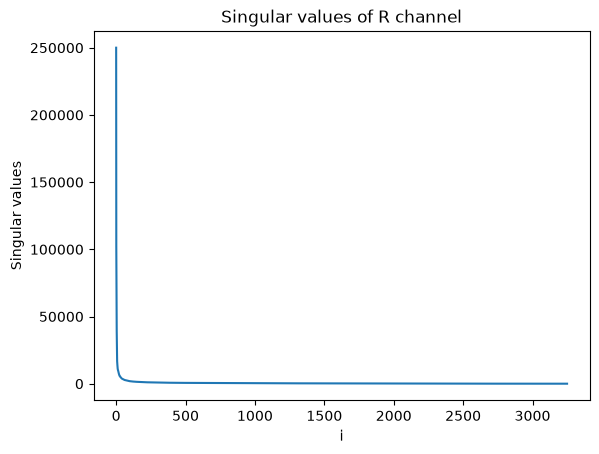

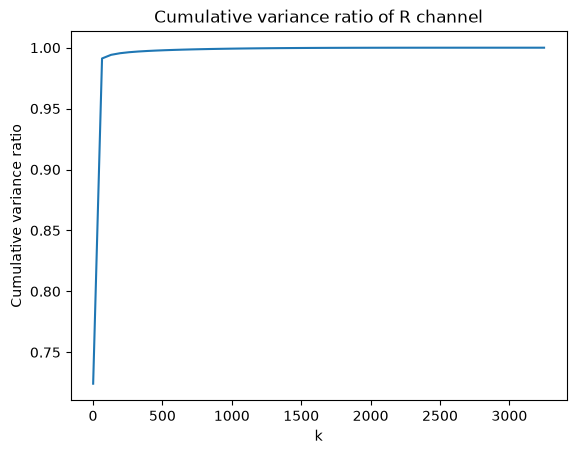

In [26]:
# 3. 用 SVD 做图像压缩（用 `plt.imshow` 展示不同 $k$ 值的效果）。
img = np.array(Image.open('./.pictures/gargantua-black-5200x3250-9621.jpg')) # 5200x3250 6.79MB
# plt.imshow(img)
def compress_image(img, k):
    compressed_channel = []
    for channel in range(3):
        U, S, Vt = np.linalg.svd(img[:, :, channel], full_matrices=False)
        U_k = U[:, :k]
        S_k = S[:k]
        Vt_k = Vt[:k, :]
        channel_comp = np.dot(U_k, np.dot(np.diag(S_k), Vt_k))
        channel_comp = np.clip(channel_comp, 0, 255).astype(np.uint8)
        compressed_channel.append(channel_comp)
    return np.stack(compressed_channel, axis=2)

# R Channel Decomposition
R = img[:, :, 0]
_, S, _ = np.linalg.svd(R, full_matrices=False)
# 在1-3250之间均匀取51 个点
k_list = np.linspace(1, 3250, 51, dtype=int)
variance_ratio = []
for k in k_list:
    # img_reduced = compress_image(img, k)
    # plt.imsave(f'./.pictures/gargantua-compressed-k{k}.jpg', img_reduced)
    # 计算累计方差比
    variance_ratio.append(np.sum(np.dot(S[:k], S[:k].T)) / np.sum(np.dot(S, S.T)))

print(f"奇异值数量：{len(S)}")
# 绘制奇异值变化
plt.plot(S)
plt.xlabel('i')
plt.ylabel('Singular values')
plt.title('Singular values of R channel')
plt.show()
# 绘制累计方差比
plt.plot(k_list, variance_ratio)
plt.xlabel('k')
plt.ylabel('Cumulative variance ratio')
plt.title('Cumulative variance ratio of R channel')
plt.show()

In [25]:
# 4. 用伪逆 `np.linalg.pinv` 解一个最小二乘问题，与 `np.linalg.lstsq` 对比。
A = np.random.rand(100, 50)
b = np.random.rand(100)
x = np.linalg.pinv(A).dot(b)
x_lstsq = np.linalg.lstsq(A, b, rcond=None)[0]
print(f"np.linalg.pinv: {x}")
print(f"np.linalg.lstsq: {x_lstsq}")
print(f"一致性：{np.allclose(x, x_lstsq)}")

np.linalg.pinv: [ 0.07179625 -0.20987827  0.04906804  0.14264564 -0.208729   -0.16386876
 -0.07380612  0.04826128  0.23647701 -0.07206696 -0.12661421  0.32078121
  0.03820893  0.09923343 -0.18714614 -0.04359134  0.15024487  0.03196001
 -0.07732591 -0.35694767 -0.05682203  0.09114343 -0.01627551  0.06075459
  0.20537407  0.01450422 -0.15847581  0.16748381 -0.1603274   0.10014855
  0.10921214  0.05818441  0.34673783  0.07339613 -0.14189437  0.12651405
  0.06363708  0.20878657  0.05167026  0.07576071  0.06394988 -0.03841567
  0.02983969  0.29721115 -0.09889343 -0.0183576  -0.01526031  0.00300923
 -0.10097559 -0.04026503]
np.linalg.lstsq: [ 0.07179625 -0.20987827  0.04906804  0.14264564 -0.208729   -0.16386876
 -0.07380612  0.04826128  0.23647701 -0.07206696 -0.12661421  0.32078121
  0.03820893  0.09923343 -0.18714614 -0.04359134  0.15024487  0.03196001
 -0.07732591 -0.35694767 -0.05682203  0.09114343 -0.01627551  0.06075459
  0.20537407  0.01450422 -0.15847581  0.16748381 -0.1603274   0.1